# **`Inatel - C318 (Tópicos Especiais II) - 2026/1`**

# <font color='green'>**Atividade 03: Pré-processamento de Dados**</font>

## <font color='#2D9CDB'>**LEIA ATENTAMENTE AS INSTRUÇÕES A SEGUIR**</font>
- Importe este notebook no [Google Colab](https://colab.research.google.com/) para resolver os exercícios;
- Consulte a apostila disponibilizada pelo professor para se familiarizar com os conceitos;
- Utilize os recursos disponíveis na Internet (documentações e artigos científicos) para complementar seus estudos;
- <font color='red'>**Uso consciente de Inteligência Artificial (LLMs):**</font>
  - O uso de assistentes (como Gemini, ChatGPT, Claude) é permitido, mas exige responsabilidade técnica:
    - Em vez de pedir a solução completa, peça para a IA explicar conceitos, sugerir abordagens ou ajudar a depurar erros de código;
    - Você é o responsável por cada linha de código entregue. Não insira no notebook implementações que você não compreende integralmente ou não saberia explicar;
    - Modelos de linguagem podem "alucinar" funções ou sugerir métodos obsoletos de bibliotecas em Python. Sempre teste e verifique a documentação oficial;
    - Quando utilizar a IA para gerar ou refatorar blocos lógicos complexos, indique isso através de comentários no próprio código;
- <font color='red'>**NÃO**</font> remova as células de Código já presentes neste notebook;
- <font color='red'>**NÃO**</font> modifique as células de Markdown (em <font color='green'>verde</font> ou <font color='#2D9CDB'>azul</font>) presentes neste notebook;
- Após cada questão, há uma célula para você implementar e responder a questão;
- É permitido adicionar mais células (de código ou markdown) antes da próxima pergunta;
- Caso precise utilizar bibliotecas que não estão instaladas nativamente no Colab, inclua uma célula de código com o comando de instalação (ex: `!pip install nome_da_biblioteca`);
- <font color='red'>**Renomeie o termo `_Enunciado` para `_seu_numero_de_matricula` no nome do arquivo (exemplo: `C318_2026_1_Atividade_03_12345.ipynb`)**</font>;
- <font color='magenta'>**Faça download do notebook com a resolução no Google Colab, mantendo a saída de todas as células, e anexe-o à tarefa do Teams.**</font>

## <font color='green'>Contextualização</font>

### <font color='#2D9CDB'>Acesse o link indicado e, em um único parágrafo, descreva brevemente o dataset, incluindo: domínio de aplicação, objetivo da base de dados e o tipo de informações que ela contém.</font>
- #### <font color='#2D9CDB'>Sakar, C. & Kastro, Y. (2018). Online Shoppers Purchasing Intention Dataset. UCI Machine Learning Repository. https://doi.org/10.24432/</font>

O dataset pertence ao domiminio de negócioos, com o objetivo de analisar o comportamento de navegação de usuários em lojas virtuais e auxiliar tarefas como classificação e predição da intenção de compra. A base contem 12330 sessões de usuários, com atributos numéricos e categóricos, incluindo quantidade de páginas visitadas, tempo gasto em páginas e métricas como bounce rate, exit rate, page value, proximidade de datas sazonais, sistema operacional, navegador, região, tipo de tráfego, tipo de visitante, mês, fim de semana e Revenue, que indica se houve compra.

## <font color='green'>Preparação</font>

In [1]:
!pip install pandas scikit-learn ucimlrepo

In [2]:
import pandas as pd
from ucimlrepo import fetch_ucirepo

ds_shoppers = fetch_ucirepo(id=468)

X_shoppers = ds_shoppers.data.features
y_shoppers = ds_shoppers.data.targets

df_shoppers = pd.concat([X_shoppers, y_shoppers], axis='columns')
df_shoppers.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


## <font color='green'>**3.1 Divisão do Dataset**</font>

### <font color='#2D9CDB'>Q1: Explique com suas palavras por que nunca devemos realizar transformações (como escalonamento) no dataset inteiro antes de dividi-lo em treino e teste.</font>

Não se escalona o dataset inteiro antes da divisão, pois isso faz parâmetros da transformação (mínimo, máximo, média e desvio padrão) serem calculados usando os dados de validação e teste. Assim, parte da informação desses conjuntos é passada para o treinamento e a avaliação se torna parcial.

### <font color='#2D9CDB'>Q2: Utilizando a função [train_test_split](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html), divida as variáveis independentes (`X_shoppers`) e a variável alvo (`y_shoppers`) em conjuntos de treinamento (80%) e teste (20%).</font>
- #### <font color='#2D9CDB'> Lembre-se de fixar uma semente do gerador de números aleatórios (`random_state`) para reprodutibilidade dos resultados.</font>

In [3]:
from sklearn.model_selection import train_test_split

X_shoppers_train, X_shoppers_test, y_shoppers_train, y_shoppers_test = train_test_split(
    X_shoppers,
    y_shoppers,
    test_size=0.20,
    random_state=1954
)

## <font color='green'>**3.2 Codificação de Atributos Categóricos**</font>

### <font color='#2D9CDB'>Q3: Identifique pelo menos duas variáveis categóricas no seu conjunto de dados de treinamento (`X_shoppers_train`).</font>

In [4]:
categoricas = X_shoppers_train.select_dtypes(include=['object', 'category']).columns.tolist()
print("Variáveis categóricas encontradas:", categoricas)

Variáveis categóricas encontradas: ['Month', 'VisitorType']


### <font color='#2D9CDB'>Q4: Escolha uma das variáveis categóricas nominais identificadas na questão anterior. Selecione essa coluna no seu conjunto de treinamento (`X_shoppers_train`) e exiba 10 amostras originais.</font>
- #### <font color='#2D9CDB'> Lembre-se de fixar uma semente do gerador de números aleatórios (`random_state`) para reprodutibilidade dos resultados.</font>

In [5]:
amostras_visitor_type = X_shoppers_train['VisitorType'].sample(n=10, random_state=1954)
print(amostras_visitor_type)

11811    Returning_Visitor
8235     Returning_Visitor
5086     Returning_Visitor
503      Returning_Visitor
4046     Returning_Visitor
4389     Returning_Visitor
9870     Returning_Visitor
6108     Returning_Visitor
7164     Returning_Visitor
8022     Returning_Visitor
Name: VisitorType, dtype: object


### <font color='#2D9CDB'>Q5: Aplique a técnica de [One-Hot Encoding](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html) na variável escolhida.</font>
- #### <font color='#2D9CDB'>Lembre-se de utilizar o método `fit_transform` no conjunto de treinamento e apenas `transform` no conjunto de teste.</font>
- #### <font color='#2D9CDB'>Observação: Ao instanciar o `OneHotEncoder`, utilize os parâmetros `sparse_output=False` (para facilitar a visualização dos dados como um array tradicional) e `handle_unknown='ignore'` (para evitar erros caso o conjunto de teste contenha alguma categoria que não existia no conjunto de treinamento).</font>

In [6]:
from sklearn.preprocessing import OneHotEncoder

coluna_ohe = ['VisitorType']
ohe = OneHotEncoder(
    sparse_output=False,
    handle_unknown='ignore'
)

X_train_ohe = ohe.fit_transform(X_shoppers_train[coluna_ohe])
X_test_ohe = ohe.transform(X_shoppers_test[coluna_ohe])

print("Treino codificado:")
print(X_train_ohe[:10])

print("\nTeste codificado:")
print(X_test_ohe[:10])

print("\nCategorias aprendidas no treino:")
print(ohe.categories_)

Treino codificado:
[[0. 0. 1.]
 [0. 0. 1.]
 [0. 0. 1.]
 [0. 0. 1.]
 [0. 0. 1.]
 [0. 0. 1.]
 [1. 0. 0.]
 [0. 0. 1.]
 [0. 0. 1.]
 [0. 0. 1.]]

Teste codificado:
[[0. 0. 1.]
 [0. 0. 1.]
 [0. 0. 1.]
 [0. 0. 1.]
 [1. 0. 0.]
 [0. 0. 1.]
 [0. 0. 1.]
 [0. 0. 1.]
 [0. 0. 1.]
 [0. 0. 1.]]

Categorias aprendidas no treino:
[array(['New_Visitor', 'Other', 'Returning_Visitor'], dtype=object)]


### <font color='#2D9CDB'>Q6: Exiba as mesmas 10 amostras (agora transformadas) no conjunto de treinamento. Explique brevemente o que aconteceu com a estrutura dos dados originais após a aplicação da técnica.</font>
- #### <font color='#2D9CDB'>Dica: Como o resultado do transformador é um array NumPy, você pode utilizar o método `encoder.get_feature_names_out()` para descobrir os nomes das novas colunas geradas e facilitar a visualização em um novo DataFrame.</font>

In [7]:
amostras_originais = X_shoppers_train[coluna_ohe].sample(n=10, random_state=1954)
amostras_transformadas = ohe.transform(amostras_originais)

amostras_transformadas_df = pd.DataFrame(
    amostras_transformadas,
    columns=ohe.get_feature_names_out(coluna_ohe),
    index=amostras_originais.index
)

print("Amostras originais:")
print(amostras_originais)

print("\nAmostras transformadas:")
print(amostras_transformadas_df)

Amostras originais:
             VisitorType
11811  Returning_Visitor
8235   Returning_Visitor
5086   Returning_Visitor
503    Returning_Visitor
4046   Returning_Visitor
4389   Returning_Visitor
9870   Returning_Visitor
6108   Returning_Visitor
7164   Returning_Visitor
8022   Returning_Visitor

Amostras transformadas:
       VisitorType_New_Visitor  VisitorType_Other  \
11811                      0.0                0.0   
8235                       0.0                0.0   
5086                       0.0                0.0   
503                        0.0                0.0   
4046                       0.0                0.0   
4389                       0.0                0.0   
9870                       0.0                0.0   
6108                       0.0                0.0   
7164                       0.0                0.0   
8022                       0.0                0.0   

       VisitorType_Returning_Visitor  
11811                            1.0  
8235              

Após a aplicação do One-Hot Encoding, a coluna original deixa de aparecer como um unico atributo em texto e passa a ser representada por várias colunas binárias, uma para cada categoria. Em cada linha, a categoria correpondente recebe 1, enquanto as outras recebem 0.

## <font color='green'>**3.3 Escalonamento de Atributos**</font>

### <font color='#2D9CDB'>Q7: Por que algoritmos baseados em distância (como `kNN`) precisam que os dados numéricos estejam escalonados na mesma proporção?</font>

Algoritimos baseados em distância precisam que os dados numéricos estejam na mesma proporção porque eles trabalham apenas sobre os valores numéricos e não entendem as unidades físicas de cada atributo. Assim, quando uma variável tem escala muito maior que outra, ela passa a dominar o cálculo da distância e influencia a decisão do modelo.

### <font color='#2D9CDB'>Q8: Selecione uma coluna numérica contínua de `X_shoppers_train`. Escreva o nome da característica selecionada abaixo.</font>

In [8]:
print(X_shoppers_train.select_dtypes(include=['int64', 'float64']).columns.tolist())
print("Característica selecionada:", 'ExitRates')

['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'OperatingSystems', 'Browser', 'Region', 'TrafficType']
Característica selecionada: ExitRates


### <font color='#2D9CDB'>Q9: Calcule e exiba as estatísticas descritivas dessa variável original (Média, Mediana, Desvio Padrão, Mínimo e Máximo).</font>

In [9]:
coluna_numerica_continua = 'ExitRates'

estatisticas = {
    'Média': X_shoppers_train[coluna_numerica_continua].mean(),
    'Mediana': X_shoppers_train[coluna_numerica_continua].median(),
    'Desvio Padrão': X_shoppers_train[coluna_numerica_continua].std(),
    'Mínimo': X_shoppers_train[coluna_numerica_continua].min(),
    'Máximo': X_shoppers_train[coluna_numerica_continua].max()
}

print(pd.Series(estatisticas))

Média            0.042982
Mediana          0.025000
Desvio Padrão    0.048688
Mínimo           0.000000
Máximo           0.200000
dtype: float64


### <font color='#2D9CDB'>Q10: Plote um gráfico mostrando sua distribuição original por meio de um [Histograma](https://seaborn.pydata.org/generated/seaborn.histplot.html)).</font>
- #### <font color='#2D9CDB'>Recomendado: adicione também uma curva de [Estimativa de Densidade de Kernel](https://pt.wikipedia.org/wiki/Estimativa_de_densidade_kernel) ao histograma; veja como no link acima.</font>

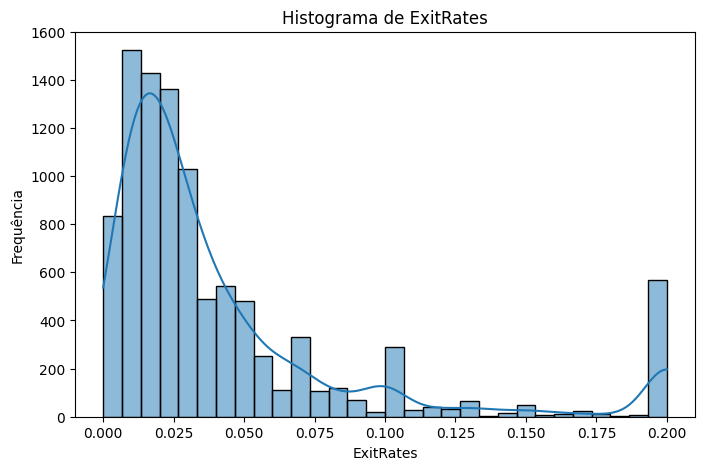

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.histplot(
    data=X_shoppers_train,
    x=coluna_numerica_continua,
    bins=30,
    kde=True
)

plt.title(f'Histograma de {coluna_numerica_continua}')
plt.xlabel(coluna_numerica_continua)
plt.ylabel('Frequência')
plt.show()

### <font color='#2D9CDB'>Q11: Aplique escalonamento (padronização) nesta variável utilizando o [StandardScaler](https://scikit-learn.org/stable/modules/generated/).</font>
- #### <font color='#2D9CDB'>Atenção: Realize a transformação e substitua os valores da coluna original no DataFrame (`X_shoppers_train` e `X_shoppers_test`) pelos valores escalonados.</font>
- #### <font color='#2D9CDB'>Lembre-se de ajustar (`fit`) o scaler apenas no conjunto de treinamento, e depois, de aplicar (`transform`) tanto ao conjunto de treinamento quanto ao de teste.</font>

In [11]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_shoppers_train[[coluna_numerica_continua]] = scaler.fit_transform(
    X_shoppers_train[[coluna_numerica_continua]]
)

X_shoppers_test[[coluna_numerica_continua]] = scaler.transform(
    X_shoppers_test[[coluna_numerica_continua]]
)

print(X_shoppers_train[[coluna_numerica_continua]].head(10))
print()
print(X_shoppers_test[[coluna_numerica_continua]].head(10))

       ExitRates
3231    3.225110
4412   -0.858825
9114   -0.724850
5106   -0.198189
4661    1.855791
11793  -0.321076
8044   -0.774744
5939   -0.395625
7325    0.486471
8581   -0.540518

       ExitRates
876    -0.235197
573     0.486471
8999   -0.211214
10244  -0.375101
11169  -0.764803
9351   -0.708571
4188    2.051408
2756    2.403518
3843   -0.369353
6993   -0.482881


### <font color='#2D9CDB'>Q12: Calcule e exiba as estatísticas descritivas dessa variável transformada (Média, Mediana, Desvio Padrão, Mínimo e Máximo).</font>

In [12]:
estatisticas_transformadas = pd.Series({
    'Média': X_shoppers_train[coluna_numerica_continua].mean(),
    'Mediana': X_shoppers_train[coluna_numerica_continua].median(),
    'Desvio Padrão': X_shoppers_train[coluna_numerica_continua].std(),
    'Mínimo': X_shoppers_train[coluna_numerica_continua].min(),
    'Máximo': X_shoppers_train[coluna_numerica_continua].max()
})

print(estatisticas_transformadas)

Média            8.211869e-17
Mediana         -3.693535e-01
Desvio Padrão    1.000051e+00
Mínimo          -8.828483e-01
Máximo           3.225110e+00
dtype: float64


### <font color='#2D9CDB'>Q13: Plote um gráfico mostrando sua distribuição transformada por meio de um [Histograma](https://seaborn.pydata.org/generated/seaborn.histplot.html).</font>
- #### <font color='#2D9CDB'>Recomendado: adicione também uma curva de [Estimativa de Densidade de Kernel](https://pt.wikipedia.org/wiki/Estimativa_de_densidade_kernel) ao histograma; veja como no link acima.</font>

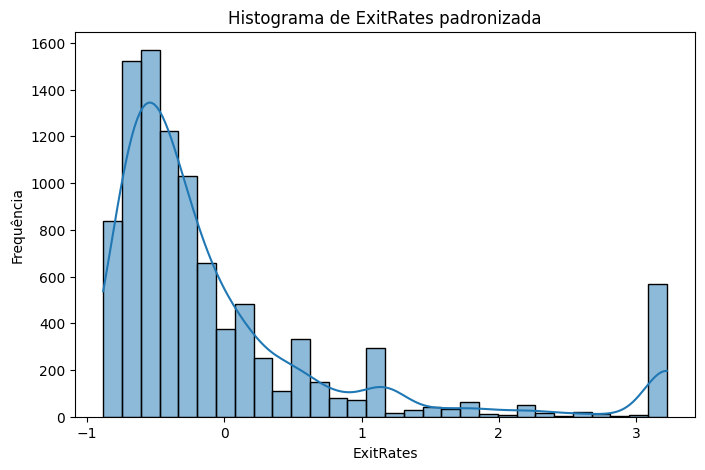

In [13]:
plt.figure(figsize=(8, 5))
sns.histplot(
    data=X_shoppers_train,
    x=coluna_numerica_continua,
    bins=30,
    kde=True
)

plt.title(f'Histograma de {coluna_numerica_continua} padronizada')
plt.xlabel(coluna_numerica_continua)
plt.ylabel('Frequência')
plt.show()

### <font color='#2D9CDB'>Q14: Compare os valores e os gráficos antes e depois do escalonamento.</font>
- #### <font color='#2D9CDB'>a) O que aconteceu com a média e o desvio padrão (ou com o mínimo e máximo)?</font>
- #### <font color='#2D9CDB'>b) O que aconteceu com a escala do eixo X?</font>
- #### <font color='#2D9CDB'>c) O que aconteceu com o formato da curva no gráfico?</font>

a) Após o escalonamento a média passou de 0,042982 para aproximadamente 0, e o desvio padrão passou de 0,048688 para aproximadamente 1. Além disso, os valores absolutos também mudaram de escala, o mínimo deixou de ser 0 e passou a ser -0.882848, e o máximo passou de 0.2 para 3.22511.

b) A escala do eixo X foram alterados. Os valores passaram a ser expressos em z-score, ou seja, em números de desvio padrão acima ou abaixo da média.

c) O formato da curva não mudou. A distribuição continuou a mesma com a mesma característica.

## <font color='green'>**3.4 Engenharia de Atributos (Feature Engineering)**</font>

### <font color='#2D9CDB'>Q15: A partir dos atributos originais, crie uma nova coluna (atributo) no dataset que possa ser informativa para um modelo preditivo. Explique a lógica da sua nova variável.</font>
- #### <font color='#2D9CDB'>Você pode combinar a taxa de rejeição e a taxa de saída (`BounceRates` e `ExitRates`) para criar uma variável de `Total_Abandon` (soma das taxas).</font>

Lógica da nova variável: Total_Abandon combina BounceRates e ExitRates em um único atributo que representa o nível de abandono ou saída da navegação. A ideia é que, em vez de o modelo analisar essas duas taxas separadamente, ele também passe a ter acesso a uma medida derivada que resume esse comportamento em uma única característica mais informativa.

In [14]:
X_shoppers['Total_Abandon'] = X_shoppers['BounceRates'] + X_shoppers['ExitRates']
print(X_shoppers[['BounceRates', 'ExitRates', 'Total_Abandon']].head(10))

   BounceRates  ExitRates  Total_Abandon
0     0.200000   0.200000       0.400000
1     0.000000   0.100000       0.100000
2     0.200000   0.200000       0.400000
3     0.050000   0.140000       0.190000
4     0.020000   0.050000       0.070000
5     0.015789   0.024561       0.040351
6     0.200000   0.200000       0.400000
7     0.200000   0.200000       0.400000
8     0.000000   0.100000       0.100000
9     0.000000   0.022222       0.022222


### <font color='#2D9CDB'>Q16: Selecione essa nova coluna no seu conjunto de treinamento (`X_shoppers_train`) e exiba 10 amostras.</font>
- #### <font color='#2D9CDB'> Lembre-se de fixar uma semente do gerador de números aleatórios (`random_state`) para reprodutibilidade dos resultados.</font>

In [15]:
X_shoppers_train['Total_Abandon'] = (
    X_shoppers_train['BounceRates'] + X_shoppers_train['ExitRates']
)

amostras_total_abandon = X_shoppers_train[['Total_Abandon']].sample(n=10, random_state=1954)

print(amostras_total_abandon)

       Total_Abandon
11811      -0.102456
8235        0.585448
5086       -0.654628
503        -0.516908
4046       -0.154475
4389       -0.599541
9870        1.171131
6108       -0.250855
7164       -0.730117
8022        0.028414


### <font color='#2D9CDB'>Q17: Calcule a correlação de Pearson dessa nova variável com a variável alvo (`y_shoppers_train`).</font>
- #### <font color='#2D9CDB'>A correlação foi negativa, neutra ou positiva? Forte ou fraca?</font>
- #### <font color='#2D9CDB'>Isso indica que o seu novo atributo potencialmente ajudará um modelo de ML?</font>
- #### <font color='#2D9CDB'>Importante: Utilize o [LabelEncoder](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.LabelEncoder.html) para transformar a variável alvo (`y_shoppers_train`) em valores numéricos (0 e 1) antes de calcular a correlação.</font>

In [21]:
from sklearn.preprocessing import LabelEncoder

X_shoppers_train['Total_Abandon'] = (
    X_shoppers_train['BounceRates'] + X_shoppers_train['ExitRates']
)

le = LabelEncoder()
y_shoppers_train_num = le.fit_transform(y_shoppers_train.values.ravel())

y_shoppers_train_num = pd.Series(
    y_shoppers_train_num,
    index=X_shoppers_train.index,
    name='Revenue_encoded'
)

# Correlação de Pearson
corr = X_shoppers_train['Total_Abandon'].corr(y_shoppers_train_num)
print(f"Correlação de Pearson: {corr:.4f}")

# Interpretação do sinal
if corr > 0:
    sinal = "positiva"
elif corr < 0:
    sinal = "negativa"
else:
    sinal = "neutra"

if abs(corr) < 0.2:
    intensidade = "muito fraca / próxima de nula"
elif abs(corr) < 0.4:
    intensidade = "fraca"
elif abs(corr) < 0.7:
    intensidade = "moderada"
else:
    intensidade = "forte"

print("Direção:", sinal)
print("Intensidade:", intensidade)

Correlação de Pearson: -0.2077
Direção: negativa
Intensidade: fraca


A correlação obtida é negativa e fraca, pois o valor obtido foi -0.2077. Isso indica que, à medida que uma variável aumenta, a outra tende a diminuir. Além disso, valores mais próximos de zero indicam associação linear mais fraca e, portanto, baixo poder preditivo isolado.


## <font color='green'>**3.5 Extração de Atributos**</font>

### <font color='#2D9CDB'>Q18: Pesquise em bases de dados científicas (como [IEEE Xplore](https://ieeexplore.ieee.org/), [arXiv](https://arxiv.org/) ou [Google Acadêmico](https://scholar.google.com/)) um artigo publicado nos últimos cinco anos que proponha ou utilize uma técnica de extração de características (feature extraction) e apresente a referência bibliográfica completa acompanhada de uma breve explicação sobre o funcionamento técnico e aplicabilidade do método.</font>

VideoMAE: Masked Autoencoders are Data-Efficient Learners for Self-Supervised Video Pre-Training
DOI: 10.48550/arXiv.2203.12602

O VideoMAE estende o conceito de MAE (Masked Autoencoder) para vídeos. Em vez de mascarar patches isolados, o método usa tube masking, isto é, mascara blocos espaço-temporais ao longo dos quadros, e treina o modelo para reconstruir o conteúdo ausente. Isso força a rede a aprender características que capturam sumiltaneamente aparência e dinâmica temporal. A aplicabilidade inclui reconhecimento de ações, indexação e recuperação de vídeos biomédicos ou industriais.

## <font color='green'>**3.6 Redução de Dimensionalidade**</font>

### <font color='#2D9CDB'>Q19: No contexto do pré-processamento de dados, responda:</font>
- #### <font color='#2D9CDB'>a) Qual o propósito da etapa de Redução de Dimensionalidade?</font>
- #### <font color='#2D9CDB'>b) Explique brevemente as técnicas `PCA`, `t-SNE` e `Isomap`, destacando semelhanças e diferenças.</font>

a) A redução de dimensionalidade tem como objetivo lidar com o problema da altas dimensionalidade, ou seja, situações em que há um número exessivo de colunas no conjunto de dados, e esse exesso pode degradar o desempenho dos algoritmos e aumentar o custo computacional.

b) PCA, t-SNE e Isomap são técnicas de redução de dimensionalidade. A PCA é uma técnica linear que projeta os dados em um novo sistema de coordenadas formado por componentes principais, ordenadas pela variância explicada. O t-SNE e o Isomap são métodos não lineares, usados para lidar com estruturas complexas como manifolds. O t-SNE prioriza a estrutura local, preservando relações de vizinhança e sendo útil para revelar clusters complexos, enquanto o Isomap prioriza a estrutura global, estimando distâncias geodésicas ao longo da superficie dos dados para capturar sua curvatura real.

### <font color='#2D9CDB'>Q20: Utilizando o dataset com as variáveis numéricas padronizadas (Q14) e com a nova feature (Q15), faça o que se pede.</font>

- #### <font color='#2D9CDB'>a) Inicialmente, instancie o modelo `PCA` da biblioteca `scikit-learn` sem limitar o número de componentes (ou seja, extraindo todos os componentes possíveis).</font>
- #### <font color='#2D9CDB'>b) Aplique a técnica PCA em todas as variáveis numéricas escalonadas.</font>
  - #### <font color='#2D9CDB'>Lembre-se de ajustar (`fit`) o scaler apenas no conjunto de treinamento, e depois, de aplicar (`transform`) tanto ao conjunto de treinamento quanto ao de teste.</font>
- #### <font color='#2D9CDB'>c) Crie um gráfico de dispersão (Scatter Plot) mostrando a variância explicada cumulativa em função do número de componentes.</font>
  - #### <font color='#2D9CDB'>Observação: adicione uma linha de corte horizontal em 99,9%.</font>
  - #### <font color='#2D9CDB'>Dica: você pode usar a função `np.cumsum()` sobre o atributo `explained_variance_ratio_` do objeto PCA.</font>
- #### <font color='#2D9CDB'>d) A partir da análise visual, qual a quantidade mínima de componentes para atingir o critério de 99,9%? Justifique por que escolher um limiar tão alto.</font>

Colunas numéricas usadas no PCA:
['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'Total_Abandon']

Número total de componentes extraídos: 15
Quantidade mínima para atingir 99,9%: 14


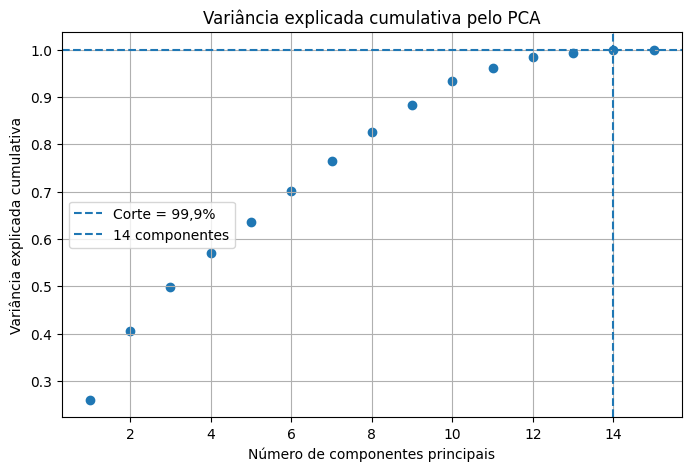

In [24]:
import numpy as np
from sklearn.decomposition import PCA

X_shoppers_train = X_shoppers_train.copy()
X_shoppers_test = X_shoppers_test.copy()

X_shoppers_train['Total_Abandon'] = (
    X_shoppers_train['BounceRates'] + X_shoppers_train['ExitRates']
)

X_shoppers_test['Total_Abandon'] = (
    X_shoppers_test['BounceRates'] + X_shoppers_test['ExitRates']
)

colunas_numericas = X_shoppers_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
print("Colunas numéricas usadas no PCA:")
print(colunas_numericas)

scaler_pca = StandardScaler()

X_train_num_scaled = scaler_pca.fit_transform(X_shoppers_train[colunas_numericas])
X_test_num_scaled = scaler_pca.transform(X_shoppers_test[colunas_numericas])

X_train_num_scaled = pd.DataFrame(
    X_train_num_scaled,
    columns=colunas_numericas,
    index=X_shoppers_train.index
)

X_test_num_scaled = pd.DataFrame(
    X_test_num_scaled,
    columns=colunas_numericas,
    index=X_shoppers_test.index
)

pca = PCA(n_components=None)

X_train_pca = pca.fit_transform(X_train_num_scaled)
X_test_pca = pca.transform(X_test_num_scaled)

variancia_explicada = pca.explained_variance_ratio_
variancia_cumulativa = np.cumsum(variancia_explicada)

# Quantidade mínima de componentes para atingir 99,9%
n_componentes_999 = np.argmax(variancia_cumulativa >= 0.999) + 1

print(f"\nNúmero total de componentes extraídos: {len(variancia_explicada)}")
print(f"Quantidade mínima para atingir 99,9%: {n_componentes_999}")

# =========================================================
# 6) Gráfico de dispersão da variância explicada cumulativa
# =========================================================
plt.figure(figsize=(8, 5))
plt.scatter(
    range(1, len(variancia_cumulativa) + 1),
    variancia_cumulativa
)
plt.axhline(y=0.999, linestyle='--', label='Corte = 99,9%')
plt.axvline(x=n_componentes_999, linestyle='--', label=f'{n_componentes_999} componentes')

plt.title('Variância explicada cumulativa pelo PCA')
plt.xlabel('Número de componentes principais')
plt.ylabel('Variância explicada cumulativa')
plt.legend()
plt.grid(True)
plt.show()

### <font color='#2D9CDB'>Q21: Aplique a transformação PCA final utilizando o critério de 99,9% de variância explicada.</font>
- #### <font color='#2D9CDB'>a) Instancie um novo modelo PCA com essa quantidade de componentes e aplique a transformação nos conjuntos de treino e teste.</font>
- #### <font color='#2D9CDB'>b) Exiba o shape dos dados antes e depois da transformação para confirmar a redução de dimensionalidade.</font>
- #### <font color='#2D9CDB'>c) Quais são os 3 principais atributos que mais influenciam a primeira Componente Principal (PC1)?</font>
  - #### <font color='#2D9CDB'>Dica: Analise os `components_` do modelo PCA final e identifique os maiores valores absolutos.</font>

### <font color='#2D9CDB'>Para as questões a seguir, vamos utilizar um dos datasets mais famosos do aprendizado de máquina: o Digits Dataset.</font>
- <font color='#2D9CDB'>Referência: E. Alpaydin and C. Kaynak. "Optical Recognition of Handwritten Digits," UCI Machine Learning Repository, 1998. https://doi.org/10.24432/C50P49</font>

<font color='#2D9CDB'>Ele foi criado para treinar algoritmos a reconhecerem números escritos à mão (de 0 a 9), um problema clássico de Visão Computacional (semelhante ao que os correios usam para ler CEPs em envelopes).</font>

- <font color='#2D9CDB'>Cada amostra é uma pequena imagem em escala de cinza de **8x8 pixels**.</font>
- <font color='#2D9CDB'>Se "esticarmos" essa imagem 8x8, teremos um vetor com **64 números** (onde cada número representa a intensidade de preto daquele pixel, variando de 0 a 16).</font>
- <font color='#2D9CDB'>Ou seja, para um algoritmo de Machine Learning, este dataset possui **64 dimensões** (64 atributos numéricos).</font>

<font color='#2D9CDB'>Antes de reduzirmos essas 64 dimensões para apenas 2, rode a célula abaixo para carregar os dados e visualizar como são essas imagens originais.</font>

### <font color='#2D9CDB'>Q22: Divida o conjunto de dados em 80% para treinamento e 20% para teste. Em seguida, mostre o número de amostras (linhas) e características (colunas) de cada subconjunto.</font>

### <font color='#2D9CDB'>Q23: Padronize o dataset utilizando o [StandardScaler](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html). Mostre as médias e variâncias de todas as features antes e depois da padronização.</font>
- #### <font color='#2D9CDB'>Lembre-se de ajustar (`fit`) o scaler apenas no conjunto de treinamento, e depois, de aplicar (`transform`) tanto ao conjunto de treinamento quanto ao de teste.</font>

### <font color='#2D9CDB'>Q24: Com os dados padronizados, faça o que se pede.</font>
- #### <font color='#2D9CDB'>a) Instancie os modelos [PCA](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html), [t-SNE](https://scikit-learn.org/stable/modules/generated/sklearn.manifold.TSNE.html) e [Isomap](https://scikit-learn.org/stable/modules/generated/sklearn.manifold.Isomap.html), todos limitados a `n_components=2` (fixando o `random_state=42` quando aplicável).</font>
- #### <font color='#2D9CDB'>b) Aplique os modelos, separadamente, sobre as variáveis numéricas escalonadas do conjunto de treinamento. </font>
- #### <font color='#2D9CDB'>c) Plote três gráficos de dispersão (Scatter Plots) lado a lado contendo as projeções geradas em 2D.
  - #### <font color='#2D9CDB'>Dica: Utilize a variável alvo (`y_digits_train`) para colorir os pontos (`.scatter(c=y_digits_train, ...)`).</font>

### <font color='#2D9CDB'>Q25: Com base nos gráficos e na teoria da apostila, comente as diferenças visuais geradas pelos algoritmos na separação das classes, relacionando com suas naturezas matemáticas (linear global, não linear local e não linear global).</font>

## <font color='green'>**3.7 Seleção de Atributos**</font>

## <font color='green'>Contextualização</font>

### <font color='#2D9CDB'>Acesse o link indicado e, em um único parágrafo, descreva brevemente o dataset, incluindo: domínio de aplicação, objetivo da base de dados e o tipo de informações que ela contém.</font>
- #### <font color='#2D9CDB'>M. Hopkins, E. Reeber, G. Forman, and J. Suermondt. "Spambase," UCI Machine Learning Repository, 1999. https://doi.org/10.24432/C53G6X</font>

## <font color='green'>Preparação</font>

In [ ]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
ds_spam = fetch_ucirepo(id=94)

# data (as pandas dataframes)
X_spam = ds_spam.data.features
y_spam = ds_spam.data.targets

df_spam = pd.concat([X_spam, y_spam], axis='columns')
df_spam.head()

### <font color='#2D9CDB'>Q26: Divida o conjunto de dados em 80% para treinamento e 20% para teste. Em seguida, mostre o número de amostras (linhas) e características (colunas) de cada subconjunto.</font>

### <font color='#2D9CDB'>Q27: Aplique a técnica de Filtro de Baixa Variância (Variance Threshold) utilizando um limiar (threshold) de 0.01. Indique quais features seriam removidas do conjunto de dados por apresentarem variância abaixo deste valor.</spam>

### <font color='#2D9CDB'>Q28: Aplique o Filtro de Multicolinearidade gerando a matriz de correlação entre as features independentes. Identifique os pares de features que possuem uma correlação absoluta maior que 0.80 (∣r∣>0.80). Indique qual(is) feature(s) você removeria para eliminar a redundância.</font>

### <font color='#2D9CDB'>Q29: Aplique o filtro de Correlação com o Alvo. Calcule a correlação de Pearson de cada feature com a variável alvo (Class). Indique quais features seriam removidas por possuírem uma correlação absoluta muito baixa, estritamente menor que 0.05 (∣r∣<0.05).</font>

### <font color='#2D9CDB'>Q28: Aplique a técnica de método de envelopamento RFE (Recursive Feature Elimination) utilizando um modelo de Regressão Logística ou Random Forest. Configure o algoritmo para selecionar apenas as 20 features mais importantes. Indique, de forma resumida, quais features foram descartadas pelo modelo.</font>
- #### <font color='#2D9CDB'>Utilize o modelo de [Regressão Logística](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html) (`LogisticRegression(max_iter=10000, random_state=42)`) como classificador subjacente do RFE.</font>

### <font color='#2D9CDB'>Q30) O algoritmo RFE não apenas seleciona as variáveis, mas cria um ranking de importância para todas elas.</font>
- #### <font color='#2D9CDB'>a) Utilizando o atributo `.ranking_` do seletor ajustado na questão anterior, construa um DataFrame que mostre o nome das features originais lado a lado com sua posição no ranking. Ordene os resultados para exibir as features selecionadas (rank 1) no topo da tabela.</font>
- #### <font color='#2D9CDB'>b) Analisando o ranking, quais "termos" (palavras, símbolos de pontuação ou métricas de texto) o modelo considerou como os mais importantes para a detecção de spam (Rank 1)?</font>
- #### <font color='#2D9CDB'>c) Analisando o ranking, quais termos demonstraram ter o menor significado preditivo, sendo eliminados nas primeiras iterações (piores posições no ranking)?</font>